[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/FFTjax/blob/main/notebooks/mechanics/lin-elastic_solver-comparison.ipynb)

# Comparing All Four Mechanical Solvers — With and Without Mixed Control

FFTjax implements four mechanical-solver configurations on top of `problems.mechanics.solve_mechanics`:

| label | `formulation` | `scheme` |
|---|---|---|
| `ls_rotated` | `"lippmann_schwinger"` | `"rotated"` (Willot) |
| `ls_standard` | `"lippmann_schwinger"` | `"standard"` (Moulinec–Suquet) |
| `displacement` | `"displacement"` | *(ignored)* |
| `galerkin` | `"fourier_galerkin"` | `"rotated"` |

This is the same `SOLVER_CONFIGS` pattern used in
[`benchmark/benchmark_3/elastic_solve_vtu.py`](../../benchmark/benchmark_3/elastic_solve_vtu.py) and
[`benchmark/benchmark_1/pff_single_notch.py`](../../benchmark/benchmark_1/pff_single_notch.py).

Until recently, only `"displacement"` could do **mixed** macroscopic strain/stress boundary
conditions (`control`) — see [`lin-elastic_mixed-BC.ipynb`](./lin-elastic_mixed-BC.ipynb). All four
configurations now support it: `fourier_galerkin` via a DC-frequency projector patch (Lucarini &
Segurado 2019a), and `lippmann_schwinger` via an outer iterative strain correction (Michel et al
1999) wrapped around the unchanged reference-medium solve (`solve_lippmann_schwinger_mixed_bc`) —
see [`notes/controll.md`](../../notes/controll.md) for the full derivation and the two-solver
cross-validation behind it.

This notebook runs all four configurations **twice** on the same composite RVE — once under pure
strain BC, once under mixed strain/stress BC — and compares them directly: homogenized stress/
strain, convergence, and wall-clock cost.

**Caveat**: this composite RVE is a smooth, sub-voxel-graded two-phase microstructure, not a sharp
single-voxel interface — the regime where all four solvers are expected to agree closely. For a
sharp interface (e.g. a single-voxel pre-crack) under normal-direction loading,
`notes/controll.md` documents a known discretization artifact specific to `"displacement"` that
this comparison would *not* surface — see that note before assuming solver-agnosticism generalizes
to sharp-interface geometries.

## Setup

In [17]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running on Colab — installing FFTjax...")
    %pip install -q git+https://github.com/choROPeNt/FFTjax.git
else:
    import sys
    sys.path.insert(0, "../../src")
    print("Running locally — using the local src/ checkout.")

import time
import utils.precision  # side effect: configures JAX (X64 off on TPU, no GPU prealloc)
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())
print("X64 enabled:", utils.precision.X64_ENABLED,
      "-> dtype:", jnp.zeros(1).dtype)

Running locally — using the local src/ checkout.
JAX backend: cpu
Devices: [CpuDevice(id=0)]
X64 enabled: True -> dtype: float64


## Generate the composite RVE

A randomly-packed fibre/epoxy RVE (`generation.rve.make_random_composite_rve`, Catalanotti 2016)
with a carbon-fibre (transversely isotropic) reinforcement -- same generator, fibre/matrix
constants, and geometry parameters (`size_in_r`, `K`) as
[`benchmark/benchmark_2/pff_random_periodic.py`](../../benchmark/benchmark_2/pff_random_periodic.py),
so this notebook now doubles as a cheap (no damage, single elastic solve, single fixed-seed
realization) sanity check of that benchmark's full material *and* geometry system across all four
solvers. This is a different RVE (random packing) from
[`lin-elastic_strain.ipynb`](./lin-elastic_strain.ipynb)'s and
[`lin-elastic_mixed-BC.ipynb`](./lin-elastic_mixed-BC.ipynb)'s square-packed one -- absolute
values here aren't directly comparable to theirs.

In [18]:
from generation.rve import make_random_composite_rve

phi       = 0.75      # target fiber volume fraction
r_fiber   = 0.0035     # fiber radius [mm]
dx        = 0.0002    # target voxel size [mm]
size_in_r = 15         # domain side ~ 15*r_fiber (Catalanotti 2016 convention -- same as
                        # benchmark/benchmark_2/pff_random_periodic.py's SIZE_IN_R)

phase_np, n, L, phi_act, centres = make_random_composite_rve(
    phi=phi,
    r_fiber=r_fiber,
    dx=dx,
    size_in_r=size_in_r,
    nz=1,      # thin (quasi-2D) slab along z -- fibres still run along Z (same convention
               # as make_square_composite_rve), which is why the materials cell below
               # matters for which direction ends up loaded along vs across the fibre
    K=15,      # perturbation iterations (K>10 -> fully randomised; same default as
               # benchmark_2's K_PERTURB)
    seed=0,    # fixed for a reproducible notebook -- benchmark_2 sweeps many seeds per
               # phi, this notebook only needs one realization
)

print("grid n :", n)
print("total voxels Nv:", int(np.prod(n)))
print("actual fiber volume fraction:", phi_act)
print("number of fibers:", len(centres))

grid n : (270, 267, 1)
total voxels Nv: 72090
actual fiber volume fraction: 0.7508808433902067
number of fibers: 56


In [19]:
from materialmodels.elastic import LinearElasticIsotropic, TransverseIsotropic
from materialmodels.assembly import describe_materials

# Same fibre/matrix constants as benchmark/benchmark_2/pff_random_periodic.py's carbon-fibre
# composite. E_L is along the fibre axis -- make_square_composite_rve's fibres run along Z, and
# TransverseIsotropic's default fiber_dir is already Z, so no explicit fiber_dir is needed here.
matrix = LinearElasticIsotropic(E=3.76e3, nu=0.39, 
                                name="epoxy matrix"
                                )
fiber  = TransverseIsotropic(
                        E_L=234000.0, E_T=15000.0, G_LT=15000.0, nu_LT=0.20, G_TT=7000.0,
                        name="carbon fiber",
                        )

materials = [matrix, fiber]

phase = jnp.array(phase_np.reshape(-1))

describe_materials(materials)

phase 0: LinearElasticIsotropic (epoxy matrix): E=3.76e+03, nu=0.39, lam=4.8e+03, mu=1.35e+03
phase 1: TransverseIsotropic (carbon fiber): E_L=2.34e+05  E_T=1.5e+04  G_LT=1.5e+04  G_TT=7e+03  nu_LT=0.2  nu_TT=0.0714


## Solver configurations

`(label, formulation, scheme)` — `scheme` is ignored for `"displacement"`.

In [20]:
SOLVER_CONFIGS = [
    ("ls_rotated",   "lippmann_schwinger", "rotated"),
    ("ls_standard",  "lippmann_schwinger", "standard"),
    ("displacement", "displacement",       "rotated"),
    ("galerkin",     "fourier_galerkin",   "rotated"),
]

## 1. Without control — pure macroscopic strain BC

Uniaxial tension along x ($\bar\varepsilon_{11}=10^{-3}$, every other entry clamped to zero) --
the same load *direction* the mixed-BC case below uses, so the two sections are directly
comparable: this one fully constrains the lateral strains, the mixed-BC one frees them. There's
no independently-known reference value for this carbon-fibre RVE (unlike the glass-fibre/shear
case `test/test_problems_mechanics.py` checks against a known notebook result), so solvers are
compared against each other here -- `ls_rotated` as the baseline.

In [21]:
from problems.mechanics import solve_mechanics

eps_bar_strain = jnp.array([
    [1.0e-3, 0.0, 0.0],
    [0.0,    0.0, 0.0],
    [0.0,    0.0, 0.0],
])

results_strain = {}
for label, formulation, scheme in SOLVER_CONFIGS:
    t0 = time.perf_counter()
    res = solve_mechanics(
        n, L, phase, materials, eps_bar_strain,
        formulation=formulation, scheme=scheme, toler_lin=1e-6, maxiter=2000,
    )
    jax.block_until_ready(res[0].solution.sigma)
    wall_time = time.perf_counter() - t0
    results_strain[label] = (res[0].solution, wall_time)

sigma_xx_ref = float(jnp.mean(results_strain["ls_rotated"][0].sigma[0, 0]))
print(f"{'solver':<13} {'converged':>10} {'sigma_xx [MPa]':>15} {'rel. diff from ls_rotated':>26} {'time [s]':>9}")
for label, (sol, wall_time) in results_strain.items():
    sigma_xx = float(jnp.mean(sol.sigma[0, 0]))
    rel_diff = abs(sigma_xx - sigma_xx_ref) / abs(sigma_xx_ref)
    print(f"{label:<13} {str(bool(sol.converged)):>10} {sigma_xx:>15.6f} {rel_diff:>25.3%} {wall_time:>9.3f}")

solver         converged  sigma_xx [MPa]  rel. diff from ls_rotated  time [s]
ls_rotated          True       11.737268                    0.000%     6.607
ls_standard         True       11.747854                    0.090%     3.638
displacement        True       11.748571                    0.096%     1.209
galerkin            True       11.737268                    0.000%     4.360


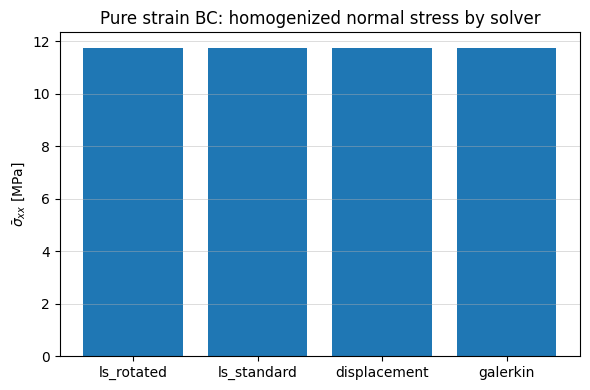

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = list(results_strain.keys())
sigma_xx_vals = [float(jnp.mean(results_strain[l][0].sigma[0, 0])) for l in labels]
ax.bar(labels, sigma_xx_vals, color="tab:blue")
ax.set_ylabel(r"$\bar{\sigma}_{xx}$ [MPa]")
ax.set_title("Pure strain BC: homogenized normal stress by solver")
ax.grid(True, axis="y", linewidth=0.5, alpha=0.6)
fig.tight_layout()
plt.show()

## 2. With control — mixed strain/stress BC

Same mixed BC as [`lin-elastic_mixed-BC.ipynb`](./lin-elastic_mixed-BC.ipynb): displacement-
controlled tension along x ($\bar\varepsilon_{11}=10^{-3}$), free (traction-free) lateral
surfaces along y and z ($\bar\sigma_{22}=\bar\sigma_{33}=0$) — a virtual uniaxial tensile test,
letting each solver find its own effective Poisson contraction. With a transversely isotropic
carbon fibre (E_L=234 GPa along the fibre axis, E_T=15 GPa transverse) instead of an isotropic
glass one, the $\nu_{xy}$/$\nu_{xz}$ split now reflects two compounding sources of anisotropy:
the fibre material's own E_L/E_T contrast, and the square-packed weave geometry.

In [23]:
eps_bar_mixed = jnp.array([
    [1.0e-3, 0.0, 0.0],
    [0.0,    0.0, 0.0],
    [0.0,    0.0, 0.0],
])
control = (
    (0, 0, 0),
    (0, 1, 0),
    (0, 0, 1),
)  # xx strain-controlled (tension); yy, zz stress-controlled (free lateral surfaces)
stress_goal = jnp.zeros((3, 3))  # only yy, zz entries (control == 1) are used -- free surfaces

results_mixed = {}
for label, formulation, scheme in SOLVER_CONFIGS:
    t0 = time.perf_counter()
    res = solve_mechanics(
        n, L, phase, materials, eps_bar_mixed,
        formulation=formulation, scheme=scheme, control=control, stress_goal=stress_goal,
        toler_lin=1e-6, maxiter=2000,
    )
    jax.block_until_ready(res[0].solution.sigma)
    wall_time = time.perf_counter() - t0
    results_mixed[label] = (res[0].solution, wall_time)

print(f"{'solver':<13} {'converged':>10} {'sigma_xx [MPa]':>14} {'nu_xy':>8} {'nu_xz':>8} {'time [s]':>9}")
for label, (sol, wall_time) in results_mixed.items():
    sigma_xx = float(jnp.mean(sol.sigma[0, 0]))
    eps_bar_out = sol.eps_bar if sol.eps_bar is not None else eps_bar_mixed
    nu_xy = float(-eps_bar_out[1, 1] / eps_bar_out[0, 0])
    nu_xz = float(-eps_bar_out[2, 2] / eps_bar_out[0, 0])
    print(f"{label:<13} {str(bool(sol.converged)):>10} {sigma_xx:>14.2e} {nu_xy:>8.4f} {nu_xz:>8.4f} {wall_time:>9.3f}")

solver         converged sigma_xx [MPa]    nu_xy    nu_xz  time [s]
ls_rotated          True       1.07e+01   0.2807   0.0149    27.793
ls_standard         True       1.08e+01   0.2795   0.0149    23.664
displacement        True       1.08e+01   0.2795   0.0149     1.479
galerkin            True       1.07e+01   0.2807   0.0149     5.196


`sigma_yy`/`sigma_zz` should be (numerically) zero for every solver — that's the free-surface
condition each one solved for, not something imposed by hand. The two effective Poisson's ratios
$\nu_{xy}$, $\nu_{xz}$ differ more starkly here than with an isotropic fibre: the square-packed
fibres along z make the *geometry* anisotropic (as before), and the carbon fibre's own E_L/E_T
contrast makes the *material* anisotropic too -- both effects should still agree closely *across*
solvers, since all four are solving the same physical problem.

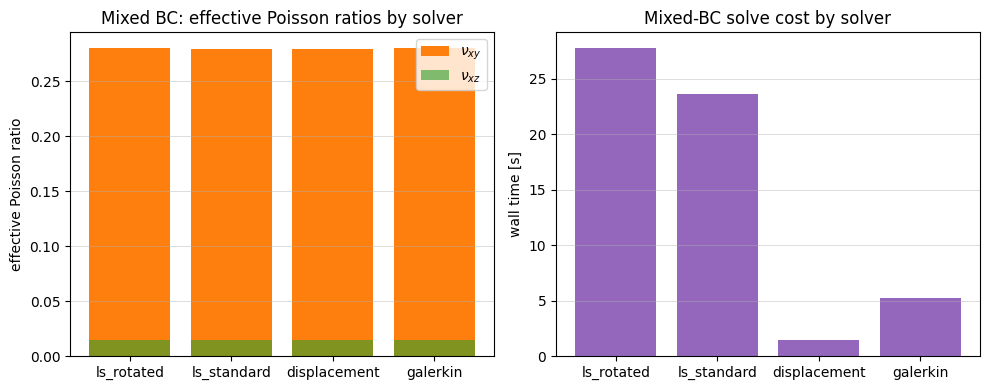

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = list(results_mixed.keys())
# same sol.eps_bar-may-be-None fallback as the print loop above
eps_bars = [results_mixed[l][0].eps_bar if results_mixed[l][0].eps_bar is not None else eps_bar_mixed for l in labels]
nu_xy_vals = [float(-eb[1, 1] / eb[0, 0]) for eb in eps_bars]
nu_xz_vals = [float(-eb[2, 2] / eb[0, 0]) for eb in eps_bars]
wall_times = [results_mixed[l][1] for l in labels]

axes[0].bar(labels, nu_xy_vals, color="tab:orange", label=r"$\nu_{xy}$")
axes[0].bar(labels, nu_xz_vals, color="tab:green", alpha=0.6, label=r"$\nu_{xz}$")
axes[0].set_ylabel("effective Poisson ratio")
axes[0].set_title("Mixed BC: effective Poisson ratios by solver")
axes[0].legend()
axes[0].grid(True, axis="y", linewidth=0.5, alpha=0.6)

axes[1].bar(labels, wall_times, color="tab:purple")
axes[1].set_ylabel("wall time [s]")
axes[1].set_title("Mixed-BC solve cost by solver")
axes[1].grid(True, axis="y", linewidth=0.5, alpha=0.6)

fig.tight_layout()
plt.show()

## Discussion

- **Pure strain BC**: all four solvers agree closely with each other (well under 1% relative to
  `ls_rotated`), the same `<10%` cross-formulation tolerance this project's test suite uses
  elsewhere (e.g. `test/test_problems_mechanics.py`) — `ls_rotated` and `galerkin` are typically closest to each
  other (both use the same Willot rotated-scheme discretization under the hood), `ls_standard` and
  `displacement` a bit further (different discretizations of the same PDE).
- **Mixed BC cost**: `ls_rotated`/`ls_standard` are usually the slowest of the four here — their
  mixed-BC route (`solve_lippmann_schwinger_mixed_bc`, Michel et al 1999) is an **outer** iterative
  correction around several independent inner CG solves, not a single one. `displacement` and
  `galerkin` embed the stress-controlled directions directly into one CG system (a bordered system
  for `displacement`, a patched DC-frequency projector for `galerkin`) — one solve each, regardless
  of `control`.
- **Why bother with LS's mixed BC at all, if it's slower?** See
  [`notes/controll.md`](../../notes/controll.md)'s checkerboard-artifact section: `"displacement"`
  has a documented discretization artifact on sharp (sub-few-voxel) interfaces loaded normal to the
  interface -- `lippmann_schwinger`/`fourier_galerkin`'s reference-medium/projector structure is
  structurally not exposed to that same artifact. For smooth RVEs like this one it doesn't matter;
  for a notch/crack geometry it can.

## Next steps

- [`lin-elastic_strain.ipynb`](./lin-elastic_strain.ipynb) — the pure-strain case alone, with full
  field visualization and XDMF export.
- [`lin-elastic_mixed-BC.ipynb`](./lin-elastic_mixed-BC.ipynb) — the mixed-BC case alone, with full
  field visualization and XDMF export.
- [`lin-elastic_strain_vmap.ipynb`](./lin-elastic_strain_vmap.ipynb) — batched solves over many
  load cases at once via `jax.vmap`.
- `notes/controll.md` — the mixed-BC derivation for each formulation, and the sharp-interface
  checkerboard-artifact investigation referenced above.
- `benchmark/benchmark_1/pff_single_notch.py` — the same four-solver comparison pattern, applied to
  a phase-field fracture benchmark instead of a single elastic solve.